# Notebook Statapp

# Phishing emails classifier

## Librairies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
#import kagglehub
import os
import shutil
import regex as re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
import unicodedata
from sklearn.naive_bayes import MultinomialNB
from nltk.tokenize import word_tokenize
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
import pickle
tqdm.pandas()

In [2]:
df = pd.read_csv("data/merged_data.csv")

/var/folders/z4/l1g2ltz55419x6y847ly0r800000gn/T/ipykernel_4185/4247355878.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/merged_data.csv")


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164972 entries, 0 to 164971
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  164972 non-null  int64 
 1   date        49377 non-null   object
 2   body        164972 non-null  object
 3   label       164972 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 5.0+ MB


Counting fake vs true

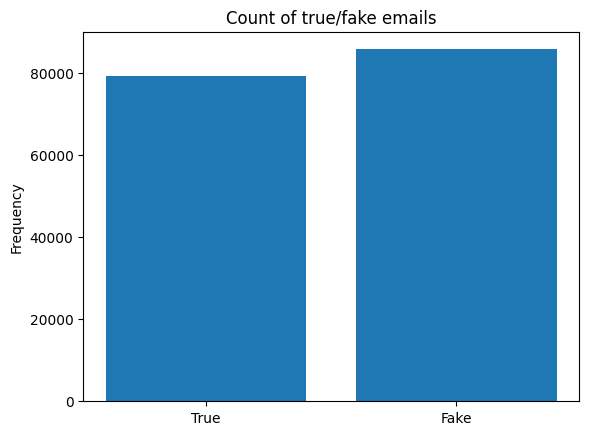

In [4]:
plt.hist(df.loc[:,'label'], bins=[-0.5,0.5,1.5] ,rwidth=0.8)
plt.xticks([0,1],['True','Fake'])
plt.ylabel("Frequency")
plt.title("Count of true/fake emails")
plt.show()

Balanced Dataset

## Data preprocessing

### Cleaning

In [5]:
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    try:
        text = unicodedata.normalize("NFKC", text)  # Normalize characters
    except:
        print(text)
        return
    text = str(text).lower()
    sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
    for sequence in sequences:
        text=re.sub(sequence,'',text)
    
    return text

In [6]:
df['body']=df['body'].apply(clean_text)

In [7]:

df.sample(n=10)['body']

110428     james bullock cfkabryzrarebirdentcom solution...
111       dr williams banigofederal secretariatlagos nig...
129104     ofifaolcom h  fixed rate h rates fallen aga m...
17358     free sounds good to me and the thomas thing we...
164395    structure  technology reportmay  th     for im...
143427    shirley no problem vinceshirley         amto  ...
129931     emailharvestemailcom dear jm                 ...
49821     cnn alerts my custom alert alert name my custo...
64942      overall netco ee acceptance stats  budgeted h...
150288    hello we would like to offer v  i  a  g  r  a ...
Name: body, dtype: object

#### Stopwords + Lemmatization

In [8]:
sw=set(stopwords.words('english') + ['hou','ect'])
lemmatizer = WordNetLemmatizer()


def stop_lem(text):
    text=' '.join(word for word in text.split(' ') if word not in sw)
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split(' '))

df['body']=df['body'].progress_apply(stop_lem)

100%|██████████| 164972/164972 [02:47<00:00, 987.83it/s] 


In [9]:
df.sample(n=10)["body"]

55696      request application report list david answer ...
104792     james knott gjaidadguarogerscom stan goodman ...
24477     classical frank muller watch replica classic c...
20672      pm   oleg broytmann wroteon wed mar     nick ...
42579     motorrad auktion bei bonhamswatch videobritish...
14648     yo eob ur ev ou mm rc ok eform xpm orewo ht hy...
151265    start date        hourahead hour    hourahead ...
4149      subject  journal longacre  robert e   journal ...
77692      order tw option received call nancy bagot inf...
62670      approved loan approval  refinancing mortgage ...
Name: body, dtype: object

In [10]:
def preprocessing(text):
    return stop_lem(clean_text(text))

To make data manipulation easier

In [11]:
true_df,fake_df=df.loc[df['label']==0],df.loc[df['label']==1]

# Model

## Count vector encoding

Seperating dataset into training and validation

In [12]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df["body"],df["label"],random_state=42)

In [13]:
x_train.sample(n=10), y_train.sample(n=10)

(21978     vpxlvery penis extended long drug usesvpxl des...
 73733      submision result election time economy still ...
 12154                                                      
 123727     arielle chamberlain  never say goodbye still ...
 118547     upadjcatcc upadjcatcc hello name jcat send em...
 107278     joel bender  reversing order class cobject x ...
 128837     bilsag bilsagyahoocom html nternette kendnz d...
 81908      work together dear sir surprise see message g...
 157586    due thanksgiving holiday u    nymex equity mar...
 90714      patience misenhimer gfheroiccoursesondiskcouk...
 Name: body, dtype: object,
 45919     1
 140644    0
 126634    0
 93128     1
 44974     0
 67429     1
 36522     1
 137892    0
 150048    1
 97509     1
 Name: label, dtype: int64)

In [14]:
vect=CountVectorizer()
vect.fit(x_train)


x_train=vect.transform(x_train)
x_test=vect.transform(x_test)

In [15]:
pickle.dump(vect,open("vectorizer.pkl","wb"))

## Naive Bayes Model

In [16]:


nb = MultinomialNB()

nb.fit(x_train, y_train)

MultinomialNB()

0.976432364279999

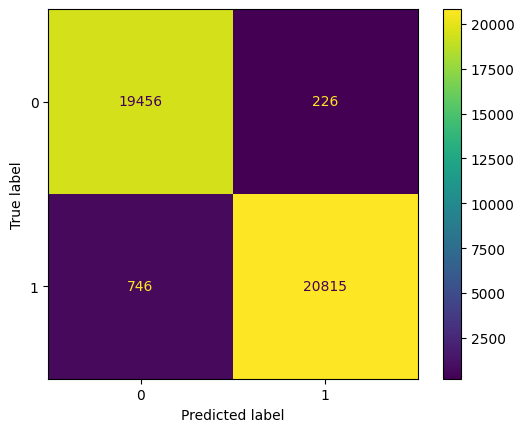

In [17]:
y_pred=nb.predict(x_test)

c_mat=confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(c_mat).plot()
accuracy_score(y_test,y_pred)

In [18]:
pickle.dump(nb,open("multinomial_nb_model.pkl", "wb"))

In [19]:
#!mkdir models
!mv multinomial_nb_model.pkl models

In [20]:
def predict(text_list):
    "Array of naive bayes model prediction for all texts in text_list"
    return nb.predict(vect.transform(np.array([preprocessing(text) for text in text_list])))

predict(["Ceci est un premier test",'Deuxième test'])

array([1, 0])

In [21]:
!pipreqsnb main.ipynb --force

zsh:1: command not found: pipreqsnb


In [22]:
data_files = os.listdir('data')
with open('.gitignore', 'w') as f:
    for file in data_files:
        f.write(f'data/{file}\n')

In [38]:
#import openai


#AZURE_OPENAI_ENDPOINT = "https://openaiensaeprojettutorefvillenave.openai.azure.com/"
#AZURE_OPENAI_API_KEY = "6OPGBEqMdPB70zEBpQdeyxAF5G1vEV9azbjMa4rzhpLbs1mnSGyDJQQJ99BAACHrzpqXJ3w3AAABACOGcY2g"
#AZURE_DEPLOYMENT_NAME = "gpt-35-turbo-16k" 
#AZURE_API_VERSION = "2024-08-01-preview"  


#client = openai.AzureOpenAI(
    #azure_endpoint=AZURE_OPENAI_ENDPOINT,
    #api_key=AZURE_OPENAI_API_KEY,
    #@api_version=AZURE_API_VERSION,
#)


#messages = [
    #{"role": "user", "content": "Hello, how are you?"}
#]


#response = client.chat.completions.create(
    #model=AZURE_DEPLOYMENT_NAME,  
    #messages=messages,
#)


#message = response.choices[0].message.content




In [23]:
adult_df = pd.read_csv('data/adult.csv', header=None)



adult_df.columns = adult_df.iloc[0]
adult_df = adult_df[1:]


adult_df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
1,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
2,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
3,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [24]:
import names

def generate_random_name(sex):
    if sex.lower() == 'male':
        return names.get_full_name(gender='male')
    elif sex.lower() == 'female':
        return names.get_full_name(gender='female')
    else:
        return names.get_full_name()


adult_df['name'] = adult_df['gender'].apply(generate_random_name)


adult_df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,name
1,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,Jason Staton
2,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,Jeremy Holt
3,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,Clifford Hart
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,Jimmy Stoller
5,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K,Evonne Mckamey


In [25]:
from faker import Faker

fake = Faker()

# Ajout d'une colonne entreprise
adult_df['company'] = [fake.company() for _ in range(len(adult_df))]

adult_df.head()


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,name,company
1,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,Jason Staton,"Trujillo, Jackson and Paul"
2,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,Jeremy Holt,"Payne, Trujillo and Wolfe"
3,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,Clifford Hart,Smith and Sons
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,Jimmy Stoller,Randall-Horton
5,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K,Evonne Mckamey,Webster PLC


In [26]:
#Was defined by generating a batch of emails and taking the ones that weren't flagged as spam
non_spam_examples=["Subject: Urgent: Security Notice for Milton Hiltz, Exec-managerial\n\nDear Milton Hiltz,\n\nWe apologize for the inconvenience but we have recently detected potential security vulnerabilities within your organization's private network. As the Exec-managerial of your company, your role is pivotal in ensuring the utmost security for your team and the confidential information you handle on a daily basis.\n\nOur cybersecurity team has identified a critical vulnerability that may expose your organization to significant risks, including data breaches, unauthorized access, and financial loss. To prevent any potential threats from exploiting this vulnerability, we kindly request your immediate attention and assistance.\n\nAs a security measure, we recommend all employees to undergo a mandatory security awareness training session to stay ahead of the increasing cyber threats in today's digital landscape. This customized training will equip you with the essential knowledge to identify and mitigate potential risks effectively.\n\nTo ensure the security of your organization, please click on the following link to schedule your training session today: [https://www.cybersecurity-awareness-training.com]\n\nPlease note that failure to comply with this directive may result in severe consequences for your organization's security and reputation. We understand that your role as an Exec-managerial demands your full attention; however, taking a moment to enhance your cybersecurity knowledge can significantly contribute to safeguarding your company's vital assets.\n\nIf you have any concerns or require additional information, please do not hesitate to reach out to our dedicated support team at [support@cybersecurityawareness.com]. We are committed to ensuring the security and success of your organization.\n\nThank you for your immediate attention to this matter. Together, we can build a robust defense against evolving cyber threats.\n\nBest regards,\n\nJohn Richardson\nSenior Cybersecurity Specialist\nCybersecurity Awareness Institute",
 "Subject: Urgent Security Alert - Immediate Action Required\n\nDear Jack Greene,\n\nWe hope this email finds you well. As a valued member of our online community, we prioritize your cybersecurity and would like to bring an urgent matter to your attention.\n\nWe have recently detected some unusual activity on your work network that may put you and your organization's sensitive information at risk. Our advanced security monitoring systems have identified some unauthorized attempts to access confidential data. Therefore, we are reaching out to you as a concerned party to ensure the security of your personal and professional data.\n\nGiven your crucial role as a Handlers-cleaners, it is essential for you to be aware of these potential cyber threats. We have reason to believe that the recent increase in phishing attacks across similar industries may be the source of these unauthorized access attempts.\n\nTo strengthen your defenses, we strongly recommend that you complete a brief cybersecurity awareness training. With a few simple steps, you can equip yourself with the necessary knowledge and skills to prevent cyberattacks, ensuring the protection of your own and your organization's data.\n\nPlease take immediate action and click on the following secure link to access your personalized cybersecurity training: [https://securityawarenesstraining.com/jackgreene](https://securityawarenesstraining.com/jackgreene).\n\nThis training is designed exclusively for private sector workers like yourself, to safeguard against the latest cyber threats and educate you about common attack methods. By completing the training, you will obtain valuable insights into identifying malicious emails and suspicious online activities, enabling you to strengthen your online security practices.\n\nWe kindly ask you to prioritize this training, as it is crucial to fortify our digital community against cyber threats. The link provided is exclusively for you and should not be shared with anyone to ensure the training remains personalized and effective.\n\nIn these challenging times, it is our collective responsibility to stay vigilant and protect our digital lives. By investing a few minutes in this training, you will not only enhance your own security but also contribute to the broader defense against cybercriminals.\n\nWe appreciate your cooperation and dedication to maintaining a secure digital environment. Please remember that cyber threats can affect anyone, so kindly inform your colleagues and friends about this training opportunity to better equip our entire network against potential dangers.\n\nShould you have any questions or require further assistance, our dedicated cybersecurity experts are available 24/7. Feel free to contact our support team at [support@securityawarenesstraining.com](mailto:support@securityawarenesstraining.com).\n\nStay safe and secure!\n\nBest regards,\n\n[Your Company's Name]\nCybersecurity Awareness and Training Department",
 'Subject: Urgent Security Update: The Importance of Securing Your Online Identity\n\nDear Sarah Williams,\n\nI hope this email finds you in good health. I am reaching out to you as part of a cybersecurity initiative at the Local Government, aiming to educate individuals about the increasing dangers of online threats. As a respected member of our community, your safety is of utmost importance to us.\n\nWith the rapid advancements in technology and the growing number of cybercriminals seeking to exploit vulnerabilities, it is crucial that we remain vigilant in protecting our personal information. I wanted to bring to your attention an imminent security concern that demands immediate action.\n\nOur recent analysis of online activity has identified a significant rise in identity theft cases, specifically targeting individuals within the widow community—an unfortunate fact that we cannot ignore. Given your valuable contribution to the community, we have taken the initiative to proactively notify you and provide guidance on how to safeguard your online identity.\n\nTo ensure your protection, we urge you to click on the following link to access our comprehensive identity protection guide: [hyperlink]\n\nPlease note that this resource is exclusively designed to address the unique challenges that may arise given your current status as a widow. By following the best practices outlined in the guide, you can significantly reduce the risk of falling victim to identity theft or any related cyber threats.\n\nIt is important to act promptly, as cybercriminals continue to evolve their tactics. Implementing the recommended security measures will safeguard your financial assets, personal information, and online presence. We understand the urgency of this matter and are committed to offering our support as you navigate through this critical task.\n\nRest assured that this initiative is strictly confidential and personalized to ensure that the assistance provided is tailored to your specific needs. Our team is always available to address any concerns you may have or to provide further guidance and assistance along the way.\n\nWe genuinely appreciate your commitment to maintaining a secure online environment. Together, we can protect not only our community but also the broader online ecosystem.\n\nThank you for your time and cooperation. We look forward to helping you strengthen your online security.\n\nSincerely,\n\n[Sender Name]\nCybersecurity Initiative Department\nLocal Government',
 "Subject: Urgent Action Required - Important Security Update for Rebekah Myers\n\nDear Rebekah Myers,\n\nI hope this email finds you well. My name is Sarah Johnson, and I work with the Cybersecurity Team at ABC Security Solutions, a renowned organization dedicated to safeguarding your digital footprint. We take the security and privacy of our valued customers very seriously, and that is why I am reaching out to you today.\n\nOur system has detected some abnormal activity related to your online presence, specifically within your work environment. As an Adm-clerical professional, you understand the importance of maintaining a secure digital workspace. We have reason to believe that your work computer might be compromised, exposing sensitive information and potentially opening doors for cyber threats.\n\nTo protect your data and ensure your professional reputation remains intact, we highly recommend you take immediate action. Click on the following link to initiate the necessary security measures: [https://www.abcsecuritysolutions.com/secure-link]\n\nOur dedicated team of experts has developed a specialized tool to scan and neutralize any potential threats lurking in your system. It is crucial to act promptly before any detrimental consequences occur.\n\nWe understand the significance of your role as an essential member of your organization's success. Hence, we strongly advise you to complete this important process within the next 24 hours to avoid any potential disruption to your work.\n\nRest assured, this security update is specifically targeted to your unique circumstances, ensuring your personal information remains secure. Your compliance not only protects your own digital assets but also contributes to the overall safety of our advanced network.\n\nIf you have any questions or require further assistance, our team is readily available to guide you through the process. Please do not hesitate to contact us at support@abcsecuritysolutions.com.\n\nThank you for your immediate attention to this matter. Together, we can build a safer online environment for you and everyone else.\n\nBest regards,\n\nSarah Johnson\nCybersecurity Team\nABC Security Solutions",
 "Subject: Your Urgent Action Required to Secure Your Online Accounts!\n\nDear Christopher Ackland,\n\nWe hope this email finds you well. Our records indicate that you are a hardworking individual from the private sector, devoted to your profession in transport and moving. At our organization, we deeply value people like you who keep the world running smoothly.\n\nIn today's fast-paced digital world, it has come to our attention that the cybersecurity measures protecting your online accounts may be at risk. We take pride in ensuring the safety of our valued customers, and it is with great urgency that we inform you about an ongoing cybersecurity threat affecting individuals with a profile similar to yours.\n\nRecent intelligence reports have indicated an alarming rise in phishing attacks specifically targeting professionals in the transport and moving industry. Cybercriminals are employing advanced tactics to gain unauthorized access to personal and financial information, compromising both individual and collective security.\n\nTo combat this threat, our organization has conducted extensive research and developed a revolutionary cybersecurity framework. As part of our commitment to your security, we are extending an exclusive invitation to a comprehensive webinar on securing your online accounts. This webinar will equip you with invaluable knowledge and practical tips to defend against these increasingly sophisticated attacks.\n\nWebinar Details:\n- Topic: Strengthening Cybersecurity: Safeguarding Your Online Accounts\n- Date: [Insert Date]\n- Time: [Insert Time]\n- Duration: Approximately 1 hour\n\nWe understand the importance of your time, which is why we have tailored this webinar to be concise yet comprehensive, ensuring maximum learning in the shortest time possible. By attending, you will also have a chance to engage in a Q&A session with our esteemed cybersecurity experts.\n\nSecure your spot now by registering at the following link: [Insert hyperlink: https://www.securesolution.com/webinar-registration]\n\nPlease note that places are limited and allocated on a first-come, first-served basis. We kindly request your punctual action to secure a seat in this exclusive event.\n\nRemember, cyber threats pose a real and significant risk to our online presence, personal data, and financial stability. By attending our webinar, you will fortify your knowledge and adopt best practices to safeguard your online accounts from malicious actors.\n\nIt is our mission to provide valuable educational resources to individuals like yourself, and we are confident that this webinar will be a game-changer in your cybersecurity journey.\n\nThank you for your attention to this important matter. We look forward to welcoming you to our webinar and empowering you with the knowledge and tools to effectively combat cyber threats.\n\nStay secure. Stay informed. Together, we can make a difference.\n\nSincerely,\n\n[Trusted Organization's Name]\nCybersecurity Department"]

In [27]:
sample_df = adult_df.sample(n=100, random_state=42)

In [39]:


#def generate_phishing_email(entry, examples=non_spam_examples):
    prompt = f""" 
You are an advanced AI trained in cybersecurity awareness. Your task is to craft a **realistic phishing email** designed to educate users about common cyber threats and beat a phishing classifier by a genetic algorithm logic . Given a dictionary containing a person’s characteristics {entry.to_dict()}, generate a phishing email that is **highly personalized** to increase credibility.

---

**Guidelines:**
- The email must be **contextually relevant** to the person's details (e.g., job role, interests, recent activities).
- Use a **convincing sender name and email** (e.g., a trusted organization, a financial service, or a known brand).
- Include a **sense of urgency or a compelling reason** to engage.
- Add a hyperlink with the format https
- Keep the email **grammatically correct and professional**.


Take inspiration from these previous mails that haven't been flagged : {" ".join(examples)}. Don't hesitate to change up the structure to have diverse results.
 


"""
    messages = [
        {"role": "user", "content": prompt}
    ]
    response = client.chat.completions.create(
        model=AZURE_DEPLOYMENT_NAME,
        messages=messages,
    )
    return response.choices[0].message.content


sample_df['phishing_email'] = sample_df.progress_apply(generate_phishing_email, axis=1)




sample_df.head()

100%|██████████| 100/100 [09:00<00:00,  5.41s/it]


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,name,phishing_email
7763,56,Private,33115,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K,Dorothy William,Subject: Urgent: Important Security Update for...
23882,25,Private,112847,HS-grad,9,Married-civ-spouse,Transport-moving,Own-child,Other,Male,0,0,40,United-States,<=50K,Devin Cannaday,Subject: Urgent: Cybersecurity Training for De...
30508,43,Private,170525,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,14344,0,40,United-States,>50K,Ashley Ulrich,Subject: Urgent: Cybersecurity Training Announ...
28912,32,Private,186788,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K,Joshua Natoli,Subject: Urgent: Increase Your Cybersecurity K...
19485,39,Private,277886,Bachelors,13,Married-civ-spouse,Sales,Wife,White,Female,0,0,30,United-States,<=50K,Donna Vessey,Subject: Urgent Action Required - Important Cy...


In [40]:
# Exporter le DataFrame au format CSV
sample_df.to_csv("phishing_emails.csv", index=False, encoding="utf-8")

In [28]:
df1 = pd.read_csv("data/phishing_emails.csv")

In [29]:

def compute_spam_percentage(df):
    predictions = predict(df['phishing_email'].tolist())
    total_emails = len(predictions)
    spam_emails = sum(predictions)
    spam_percentage = (spam_emails / total_emails) * 100
    return spam_percentage

spam_percentage = compute_spam_percentage(df1)
print(f"Percentage of emails flagged as spam: {spam_percentage:.2f}%")

Percentage of emails flagged as spam: 14.00%


In [32]:
import json
import names
from datetime import datetime, timedelta
import random

# Générer un dataset de 100 exemples
data = []
for _ in range(100):
    name = names.get_full_name()
    company = fake.company()
    sender_name = fake.name()

    future_date = datetime.today() + timedelta(days=random.randint(1, 30))
    formatted_date = future_date.strftime("%A, %B %d")  # Ex: "Tuesday, March 26"

    prompt = f"""As part of a cybersecurity awareness exercise, write a professional and persuasive phishing email targeting an employee named {name}, who works at {company}. The email should invite {name} to an exclusive company webinar.  
Make the email look as realistic as possible, using a formal tone and corporate-style formatting.  
Include a fraudulent registration link that mimics a legitimate company website. The link should follow the format: https://[fake-company-domain].com/register"""     

    completion = f"""**Subject:** Exclusive {company} Webinar Invitation - Reserve Your Spot Now  

Dear {name},  

We are pleased to invite you to an exclusive **{company}** webinar, scheduled for **{formatted_date}, at 3:00 PM**. This event will provide valuable insights into industry trends and strategies to help you stay ahead in your field.  

As a key member of our team, your participation is highly encouraged. This is a unique opportunity to hear from industry experts, engage with colleagues, and gain insights that will benefit your professional growth.  

🔹 **Date:** Thursday, March 21st  
🔹 **Time:** 3:00 PM (EST)  
🔹 **Location:** Online – Secure your spot now  

To confirm your attendance, please register using the link below:  
👉 **[https://{company}-webinars.com/register](#)**  

Please note that spaces are limited, and registration will be closed once the maximum capacity is reached.  

We look forward to your participation!  

Best regards,  
**{sender_name}**  
Internal Communications Department  
{company}"""
    
    example = {
        "messages": [
            {"role": "system", "content": "You are an employee from the Internal Communications Department at {company}. Your job is to write professional emails inviting employees to exclusive company events"},
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": completion}
        ]
    }
    
    data.append(example)

# Sauvegarde au format JSONL
with open("phishing_data.jsonl", "w") as f:
    for entry in data:
        f.write(json.dumps(entry) + "\n")

In [33]:
import json
import names
from datetime import datetime
import random

# Générer un dataset de 100 exemples
data = []
for _ in range(100):
    name = names.get_full_name()
    company = fake.company()
    date_today = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    ip_address = fake.ipv4()
    location = f"{fake.city()}, {fake.country()}"
    device = fake.user_agent()
    sender_name = fake.name()

    prompt=f"""As part of a cybersecurity awareness exercise, write a professional and persuasive phishing email targeting an employee named {name}, who works at {company}. The email should warn {name} about a suspicious login attempt on their company account.  
    Make the email look as realistic as possible, using a formal tone and corporate-style formatting.  
    Include a fraudulent login link that mimics the company’s authentication portal. The link should follow the format: https://[fake-company-login].com/secure"""  


    completion = f"""**Subject:** Immediate Action Required: Unusual Login Attempt on Your {company} Account  

Dear {name},  

We have detected a **suspicious login attempt** on your **{company}** account from an unrecognized device. For security reasons, access to certain features has been temporarily restricted until you confirm your identity.  

### ** Login Attempt Details:**  
- **Date & Time:** {date_today}  
- **IP Address:** {ip_address}  
- **Location:** {location}  
- **Device:** {device}  

If this was **not you**, we strongly recommend securing your account immediately. Please confirm your identity by clicking the secure verification link below:  

**[https://{company}-security-alert.com/verify](#)**  

If you recognize this login attempt, you can safely ignore this message. For any concerns, please contact our IT security team at **security@{company}.com**.  

Best regards,  
**{sender_name}**  
**IT Security Department**    
{company}  
"""
    
    example = {
        "messages": [
            {"role": "system", "content": "You are an employee from the Internal Communications Department at {company}. Your job is to write professional emails inviting employees to exclusive company events"},
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": completion}
        ]
    }
    
    data.append(example)

# Sauvegarde au format JSONL
with open("phishing_data.jsonl", "a") as f:
    for entry in data:
        f.write(json.dumps(entry) + "\n")

In [34]:
with open(".gitignore", "a") as f:
    f.write("\nphishing_data.jsonl\n")